# SimCLR and Supervised Contrastive Learning
### Rust / Corrosion Detection — Representation Learning Pipeline

**Goal:** Learn a feature encoder that separates CORROSION from all other surface textures.

**Pipeline:**
- **Section 1** — Setup & Data
- **Section 2** — SimCLR (self-supervised pretraining, no labels)
- **Section 3** — SupCon (supervised contrastive, all 8 classes)
- **Section 4** — Two-Stage: SimCLR backbone → SupCon fine-tune
- **Section 5** — Final Comparison
- **Section 6** — Rejection Thresholding on unknown surfaces

## Colab Setup
Run the cells in this section first before anything else.

In [1]:
# Install missing packages (Colab already has torch, torchvision, sklearn)
# !pip install -q nbformat

In [2]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# # Unzip dataset from Drive into Colab's fast local storage (/content/)
# # Upload rust_dataset.zip to your Google Drive first, then update the path below

# import zipfile, os

# ZIP_PATH  = "/content/drive/MyDrive/rust_dataset.zip"   # <-- update if needed
# DEST_PATH = "/content/"

# if not os.path.exists("/content/rust_dataset"):
#     print("Unzipping dataset...")
#     with zipfile.ZipFile(ZIP_PATH, "r") as z:
#         z.extractall(DEST_PATH)
#     print("Done.")
# else:
#     print("Dataset already unzipped.")

In [4]:
# # Set working directory to /content so all paths resolve correctly
# import os
# os.chdir("/content")
# print("Working directory:", os.getcwd())

## Section 1 — Setup & Data

In [5]:
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms, models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
# Global config

SEED     = 42
IMG_SIZE = 224
NUM_WORKERS = 0

DATA_ROOT    = Path("rust_dataset_2")
TRAIN_DIR    = DATA_ROOT / "train"
VAL_DIR      = DATA_ROOT / "test"
UNKNOWN_DIR  = DATA_ROOT / "unknown_val"

# SimCLR
SIMCLR_PROJ_DIM = 128
SIMCLR_TEMP     = 0.5
SIMCLR_LR       = 1e-3
SIMCLR_EPOCHS   = 50
SIMCLR_BATCH    = 128

# SupCon
SUPCON_PROJ_DIM = 128
SUPCON_TEMP     = 0.1
SUPCON_LR   = 1e-3
SUPCON_EPOCHS   = 50
SUPCON_BATCH    = 128

# ImageFolder sorts alphabetically — CORROSION = index 0
CORROSION_IDX = 0

In [27]:
# Device setup

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple MPS")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

print("Device:", DEVICE)

Using Apple MPS
Device: mps


In [28]:
# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("Seed set.")

Seed set.


In [29]:
# Transforms

class TwoCropTransform:
    # returns two independently augmented views of the same image
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)


# strong augmentation for SimCLR / SupCon training
_strong_aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

two_crop_transform = TwoCropTransform(_strong_aug)

# standard single-crop for feature extraction / eval
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Transforms ready.")

Transforms ready.


In [30]:
# Datasets and DataLoaders

# two-crop datasets (for training SimCLR and SupCon)
train_ds_twocrop = datasets.ImageFolder(TRAIN_DIR, transform=two_crop_transform)
train_dl_simclr  = DataLoader(train_ds_twocrop, batch_size=SIMCLR_BATCH,
                               shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
train_dl_supcon  = DataLoader(train_ds_twocrop, batch_size=SUPCON_BATCH,
                               shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)

# single-crop datasets (for feature extraction / evaluation)
train_ds_eval = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
val_ds_eval   = datasets.ImageFolder(VAL_DIR,   transform=eval_transform)
train_dl_eval = DataLoader(train_ds_eval, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
val_dl_eval   = DataLoader(val_ds_eval,   batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

# unknown_val for rejection evaluation
unknown_ds  = datasets.ImageFolder(UNKNOWN_DIR, transform=eval_transform)
unknown_dl  = DataLoader(unknown_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

CLASS_NAMES = train_ds_eval.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print(f"Train samples : {len(train_ds_eval)}")
print(f"Val samples   : {len(val_ds_eval)}")
print(f"Unknown samples: {len(unknown_ds)}")

Classes: ['CORROSION', 'HARD_NEGATIVE', 'NOCORROSION']
Train samples : 2432
Val samples   : 754
Unknown samples: 173


## Section 2 — SimCLR (Self-Supervised Pretraining)

- no labels used during training
- two augmented views of each image are pushed together, all other pairs pushed apart
- NT-Xent loss with temperature scaling
- after training: extract backbone features and evaluate with a linear probe

In [11]:
# SimCLR model — ResNet18 backbone + 2-layer MLP projector

class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder  = nn.Sequential(*list(base.children())[:-1])  # [B, 512, 1, 1]
        self.feat_dim = base.fc.in_features  # 512
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)   # [B, 512]
        z = self.projector(h)                          # [B, proj_dim]
        return h, F.normalize(z, dim=1)

In [12]:
# NT-Xent loss (SimCLR loss)
# positives = augmented pair of the same image
# negatives = all other images in the batch

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temp = temperature

    def forward(self, z1, z2):
        N  = z1.size(0)
        z  = torch.cat([z1, z2], dim=0)                    # [2N, D]
        sim = torch.mm(z, z.T) / self.temp                  # [2N, 2N]

        # positive pairs: (i, i+N) and (i+N, i)
        pos = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)])  # [2N]

        # mask out self-similarity
        mask = ~torch.eye(2 * N, dtype=torch.bool, device=z.device)
        neg  = sim[mask].view(2 * N, -1)                    # [2N, 2N-1]

        logits = torch.cat([pos.unsqueeze(1), neg], dim=1)  # [2N, 2N]
        labels = torch.zeros(2 * N, dtype=torch.long, device=z.device)
        return F.cross_entropy(logits, labels)

In [13]:
# SimCLR training — one epoch

def train_simclr_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for (view1, view2), _ in dataloader:   # labels ignored
        view1 = view1.to(device)
        view2 = view2.to(device)

        optimizer.zero_grad()
        _, z1 = model(view1)
        _, z2 = model(view2)
        loss  = criterion(z1, z2)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * view1.size(0)

    return running_loss / len(dataloader.dataset)

In [14]:
# SimCLR full training loop

def fit_simclr_model(model, dataloader, criterion, optimizer, device,
                     epochs=20, checkpoint_path=None):
    history = {"train_loss": []}
    best_loss  = float("inf")
    best_state = None

    for epoch in range(epochs):
        loss = train_simclr_one_epoch(model, dataloader, criterion, optimizer, device)
        history["train_loss"].append(loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f}")

        if loss < best_loss:
            best_loss  = loss
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_loss

In [15]:
# train SimCLR

simclr_model     = SimCLR(proj_dim=SIMCLR_PROJ_DIM).to(DEVICE)
simclr_criterion = NTXentLoss(temperature=SIMCLR_TEMP)
simclr_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=SIMCLR_LR)

simclr_model, simclr_history, simclr_best_loss = fit_simclr_model(
    simclr_model,
    train_dl_simclr,
    simclr_criterion,
    simclr_optimizer,
    DEVICE,
    epochs=SIMCLR_EPOCHS,
    checkpoint_path="simclr_best.pt",
)

print(f"\nBest SimCLR loss: {simclr_best_loss:.4f}")

Epoch 01/50 | loss=4.2387
Epoch 02/50 | loss=4.0415
Epoch 03/50 | loss=3.9874
Epoch 04/50 | loss=3.9507
Epoch 05/50 | loss=3.9518
Epoch 06/50 | loss=3.9356
Epoch 07/50 | loss=3.9153
Epoch 08/50 | loss=3.9128
Epoch 09/50 | loss=3.8915
Epoch 10/50 | loss=3.8969
Epoch 11/50 | loss=3.8774
Epoch 12/50 | loss=3.8868
Epoch 13/50 | loss=3.8725
Epoch 14/50 | loss=3.8768
Epoch 15/50 | loss=3.8690
Epoch 16/50 | loss=3.8629
Epoch 17/50 | loss=3.8609
Epoch 18/50 | loss=3.8528
Epoch 19/50 | loss=3.8489
Epoch 20/50 | loss=3.8430
Epoch 21/50 | loss=3.8486
Epoch 22/50 | loss=3.8406
Epoch 23/50 | loss=3.8464
Epoch 24/50 | loss=3.8390
Epoch 25/50 | loss=3.8379
Epoch 26/50 | loss=3.8323
Epoch 27/50 | loss=3.8335
Epoch 28/50 | loss=3.8215
Epoch 29/50 | loss=3.8252
Epoch 30/50 | loss=3.8187
Epoch 31/50 | loss=3.8113
Epoch 32/50 | loss=3.8149
Epoch 33/50 | loss=3.8149
Epoch 34/50 | loss=3.8122
Epoch 35/50 | loss=3.8147
Epoch 36/50 | loss=3.8127
Epoch 37/50 | loss=3.8097
Epoch 38/50 | loss=3.8115
Epoch 39/50 

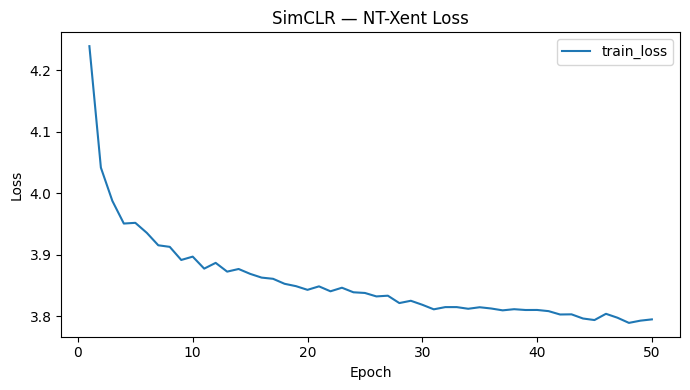

In [16]:
# plot SimCLR training loss

def plot_history(history, title="Training"):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(simclr_history, title="SimCLR — NT-Xent Loss")

In [17]:
# extract features from SimCLR backbone

def extract_embeddings(encoder_fn, dataloader, device):
    # encoder_fn: callable that takes a batch and returns (h, z)
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            h, _   = encoder_fn(images)
            all_h.append(h.cpu())
            all_labels.append(labels.cpu())
    Z = torch.cat(all_h,      dim=0)
    y = torch.cat(all_labels, dim=0)
    return Z, y

def l2_normalize_torch(Z, eps=1e-12):
    return Z / (Z.norm(dim=1, keepdim=True) + eps)

simclr_model.eval()
H_simclr_train, y_train = extract_embeddings(simclr_model, train_dl_eval, DEVICE)
H_simclr_val,   y_val   = extract_embeddings(simclr_model, val_dl_eval,   DEVICE)

H_simclr_train_l2 = l2_normalize_torch(H_simclr_train)
H_simclr_val_l2   = l2_normalize_torch(H_simclr_val)

print(f"SimCLR train features : {H_simclr_train.shape}")
print(f"SimCLR val   features : {H_simclr_val.shape}")

SimCLR train features : torch.Size([2432, 512])
SimCLR val   features : torch.Size([754, 512])


In [18]:
# binary linear probe — CORROSION vs everything else

def run_linear_probe(Z_train, y_train, Z_val, y_val, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(Z_train.numpy(), y_train.numpy())
    train_acc = accuracy_score(y_train.numpy(), clf.predict(Z_train.numpy()))
    val_acc   = accuracy_score(y_val.numpy(),   clf.predict(Z_val.numpy()))
    print(f"{label:30s} | train={train_acc:.4f} | val={val_acc:.4f}")
    return train_acc, val_acc

# binary labels: CORROSION=1, everything else=0
y_train_bin = (y_train == CORROSION_IDX).long()
y_val_bin   = (y_val   == CORROSION_IDX).long()

print("SimCLR — Binary Linear Probe (CORROSION vs rest)")
print("-" * 60)
simclr_bin_raw_train, simclr_bin_raw_val = run_linear_probe(
    H_simclr_train, y_train_bin, H_simclr_val, y_val_bin, label="simclr_h_raw"
)
simclr_bin_l2_train, simclr_bin_l2_val = run_linear_probe(
    H_simclr_train_l2, y_train_bin, H_simclr_val_l2, y_val_bin, label="simclr_h_l2"
)

SimCLR — Binary Linear Probe (CORROSION vs rest)
------------------------------------------------------------
simclr_h_raw                   | train=0.9507 | val=0.9098
simclr_h_l2                    | train=0.8832 | val=0.8820


In [19]:
# multi-class linear probe — all 8 classes

print("SimCLR — Multi-class Linear Probe (8 classes)")
print("-" * 60)
run_linear_probe(H_simclr_train,    y_train, H_simclr_val,    y_val, label="simclr_h_raw  (multi)")
run_linear_probe(H_simclr_train_l2, y_train, H_simclr_val_l2, y_val, label="simclr_h_l2   (multi)")

SimCLR — Multi-class Linear Probe (8 classes)
------------------------------------------------------------
simclr_h_raw  (multi)          | train=0.9733 | val=0.9032
simclr_h_l2   (multi)          | train=0.8635 | val=0.8753


(0.8634868421052632, 0.8753315649867374)

### short interpretation
- SimCLR is trained without labels — the binary val accuracy reflects how much the encoder naturally separates corrosion from other textures
- L2 normalisation often improves cosine-based classifiers
- Multi-class accuracy is an indicator of overall representation quality

## Section 3 — Supervised Contrastive Learning (SupCon)

- uses class labels to define positives: all images of the same class are positives
- trains on all 8 classes — more classes = richer hard negatives for CORROSION
- evaluates both backbone features `h` (512-dim) and projection features `z` (128-dim)
- binary downstream task: CORROSION vs rest

In [20]:
# SupCon model — same architecture as SimCLR

class ResNet18SupCon(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)

In [21]:
# SupCon loss
# positives = all images of the same class in the batch (not just the augmented pair)

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temp = temperature

    def forward(self, features, labels):
        # features: [B, 2, proj_dim] — two views per image
        # labels:   [B]
        device = features.device
        B = features.shape[0]

        # reshape to [2B, proj_dim] and expand labels to [2B]
        f      = features.view(2 * B, -1)
        labels = labels.repeat(2)

        # similarity matrix [2B, 2B]
        sim = torch.mm(f, f.T) / self.temp

        # positive mask: same class, different sample
        labels_eq = labels.unsqueeze(0) == labels.unsqueeze(1)   # [2B, 2B]
        self_mask = ~torch.eye(2 * B, dtype=torch.bool, device=device)
        pos_mask  = labels_eq & self_mask

        # log-sum-exp over all non-self pairs
        exp_sim  = torch.exp(sim) * self_mask
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        # average over positives
        mean_log_prob = (pos_mask * log_prob).sum(dim=1) / (pos_mask.sum(dim=1) + 1e-12)
        loss = -mean_log_prob.mean()
        return loss

In [22]:
# SupCon training — one epoch

def prepare_supcon_batch(view1, view2):
    # stack two views into [B, 2, C, H, W]
    return torch.stack([view1, view2], dim=1)

def train_supcon_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for (view1, view2), labels in dataloader:
        view1  = view1.to(device)
        view2  = view2.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        _, z1 = model(view1)
        _, z2 = model(view2)

        features = prepare_supcon_batch(z1, z2)   # [B, 2, proj_dim]
        loss     = criterion(features, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * view1.size(0)

    return running_loss / len(dataloader.dataset)

In [23]:
def fit_supcon_model(model, dataloader, criterion, optimizer, device,
                     epochs=50, checkpoint_path=None):
    history = {"train_loss": []}
    best_loss  = float("inf")
    best_state = None
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(epochs):
        loss = train_supcon_one_epoch(model, dataloader, criterion, optimizer, device)
        history["train_loss"].append(loss)
        scheduler.step()

        print(f"Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f}")

        if loss < best_loss:
            best_loss  = loss
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_loss

In [24]:
print(SUPCON_EPOCHS)

50


In [32]:
# train SupCon from scratch

supcon_model = ResNet18SupCon(proj_dim=SUPCON_PROJ_DIM).to(DEVICE)

# freeze all layers except layer4 and projector
for name, param in supcon_model.encoder.named_parameters():
    if "layer4" not in name:
        param.requires_grad = False

supcon_criterion = SupConLoss(temperature=SUPCON_TEMP)
supcon_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, supcon_model.parameters()), lr=SUPCON_LR
)

supcon_model, supcon_history, supcon_best_loss = fit_supcon_model(
    supcon_model,
    train_dl_supcon,
    supcon_criterion,
    supcon_optimizer,
    DEVICE,
    epochs=SUPCON_EPOCHS,
    checkpoint_path="supcon_best.pt",
)


print(f"\nBest SupCon loss: {supcon_best_loss:.4f}")

Epoch 01/50 | loss=5.5540
Epoch 02/50 | loss=5.5413


KeyboardInterrupt: 

In [ ]:
plot_history(supcon_history, title="SupCon — Supervised Contrastive Loss")

In [ ]:
# extract SupCon embeddings — both h (backbone) and z (projection)

def extract_supcon_embeddings(model, dataloader, device):
    model.eval()
    all_h, all_z, all_labels = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            h, z   = model(images)
            all_h.append(h.cpu())
            all_z.append(z.cpu())
            all_labels.append(labels.cpu())
    H = torch.cat(all_h,      dim=0)
    Z = torch.cat(all_z,      dim=0)
    y = torch.cat(all_labels, dim=0)
    return H, Z, y

H_supcon_train, Z_supcon_train, y_train = extract_supcon_embeddings(supcon_model, train_dl_eval, DEVICE)
H_supcon_val,   Z_supcon_val,   y_val   = extract_supcon_embeddings(supcon_model, val_dl_eval,   DEVICE)

H_supcon_train_l2 = l2_normalize_torch(H_supcon_train)
H_supcon_val_l2   = l2_normalize_torch(H_supcon_val)
Z_supcon_train_l2 = l2_normalize_torch(Z_supcon_train)
Z_supcon_val_l2   = l2_normalize_torch(Z_supcon_val)

print(f"SupCon h features: {H_supcon_train.shape}")
print(f"SupCon z features: {Z_supcon_train.shape}")

In [ ]:
# linear probe comparison — h vs z, raw vs l2, binary

y_train_bin = (y_train == CORROSION_IDX).long()
y_val_bin   = (y_val   == CORROSION_IDX).long()

print("SupCon — Binary Linear Probe (CORROSION vs rest)")
print("-" * 60)
sc_h_raw  = run_linear_probe(H_supcon_train,    y_train_bin, H_supcon_val,    y_val_bin, "supcon_h_raw")
sc_h_l2   = run_linear_probe(H_supcon_train_l2, y_train_bin, H_supcon_val_l2, y_val_bin, "supcon_h_l2")
sc_z_raw  = run_linear_probe(Z_supcon_train,    y_train_bin, Z_supcon_val,    y_val_bin, "supcon_z_raw")
sc_z_l2   = run_linear_probe(Z_supcon_train_l2, y_train_bin, Z_supcon_val_l2, y_val_bin, "supcon_z_l2")

In [ ]:
# kNN comparison

def run_knn(Z_train, y_train, Z_val, y_val, k_values=None, metric="cosine", label=""):
    if k_values is None:
        k_values = [1, 3, 5, 7, 11, 15]
    best_val, best_k = -1.0, -1
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(Z_train.numpy(), y_train.numpy())
        val_acc = accuracy_score(y_val.numpy(), knn.predict(Z_val.numpy()))
        if val_acc > best_val:
            best_val, best_k = val_acc, k
    print(f"{label:30s} | best_k={best_k} | val={best_val:.4f}")
    return best_val, best_k

print("SupCon — Binary kNN (CORROSION vs rest)")
print("-" * 60)
run_knn(H_supcon_train_l2, y_train_bin, H_supcon_val_l2, y_val_bin, label="supcon_h_l2 cosine", metric="cosine")
run_knn(H_supcon_train,    y_train_bin, H_supcon_val,    y_val_bin, label="supcon_h_raw euclidean", metric="euclidean")
run_knn(Z_supcon_train_l2, y_train_bin, Z_supcon_val_l2, y_val_bin, label="supcon_z_l2 cosine", metric="cosine")

In [ ]:
# prototype classifier

def compute_class_prototypes(Z, y, num_classes):
    prototypes = []
    for c in range(num_classes):
        mask  = (y == c)
        proto = Z[mask].mean(dim=0)
        prototypes.append(proto)
    return torch.stack(prototypes, dim=0)

def predict_by_cosine(Z, prototypes):
    Z_norm    = F.normalize(Z, dim=1)
    P_norm    = F.normalize(prototypes, dim=1)
    sim       = torch.mm(Z_norm, P_norm.T)
    return sim.argmax(dim=1)

print("SupCon — Binary Prototype Classifier (CORROSION vs rest)")
print("-" * 60)

# binary prototypes: class 0 = non-corrosion (all others), class 1 = corrosion
def binary_prototype_eval(Z_train, y_train_bin, Z_val, y_val_bin, label=""):
    protos     = compute_class_prototypes(Z_train, y_train_bin, num_classes=2)
    train_preds = predict_by_cosine(Z_train, protos)
    val_preds   = predict_by_cosine(Z_val,   protos)
    train_acc   = accuracy_score(y_train_bin.numpy(), train_preds.numpy())
    val_acc     = accuracy_score(y_val_bin.numpy(),   val_preds.numpy())
    print(f"{label:30s} | train={train_acc:.4f} | val={val_acc:.4f}")
    return val_acc

binary_prototype_eval(H_supcon_train_l2, y_train_bin, H_supcon_val_l2, y_val_bin, "supcon_h_l2")
binary_prototype_eval(Z_supcon_train_l2, y_train_bin, Z_supcon_val_l2, y_val_bin, "supcon_z_l2")

### short interpretation
- `h` features (512-dim backbone) are typically stronger than `z` projection features for downstream tasks
- L2 normalisation improves cosine-based classifiers (kNN, prototype) but has less effect on linear probe
- SupCon trains with 8 classes — hard negatives like STAINS and MUD teach the encoder what CORROSION is not

## Section 4 — Two-Stage Pipeline: SimCLR → SupCon

- initialise the SupCon encoder from the SimCLR pretrained backbone
- fine-tune with SupCon loss on labelled data
- hypothesis: SimCLR backbone provides a better starting point than ImageNet weights alone

In [ ]:
# initialise SupCon model from SimCLR backbone weights

supcon_2stage = ResNet18SupCon(proj_dim=SUPCON_PROJ_DIM).to(DEVICE)
supcon_2stage.encoder.load_state_dict(simclr_model.encoder.state_dict())

print("Loaded SimCLR backbone into SupCon model.")
print(f"Encoder params: {sum(p.numel() for p in supcon_2stage.encoder.parameters()):,}")

In [ ]:
# fine-tune with SupCon loss

supcon_2stage_criterion = SupConLoss(temperature=SUPCON_TEMP)
supcon_2stage_optimizer = torch.optim.Adam(supcon_2stage.parameters(), lr=SUPCON_LR)

supcon_2stage, supcon_2stage_history, supcon_2stage_best_loss = fit_supcon_model(
    supcon_2stage,
    train_dl_supcon,
    supcon_2stage_criterion,
    supcon_2stage_optimizer,
    DEVICE,
    epochs=SUPCON_EPOCHS,
    checkpoint_path="supcon_2stage_best.pt",
)

print(f"\nBest two-stage SupCon loss: {supcon_2stage_best_loss:.4f}")

In [ ]:
# compare training curves

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(supcon_history["train_loss"],       label="SupCon (scratch)")
ax.plot(supcon_2stage_history["train_loss"],label="SupCon (SimCLR init)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("SupCon Loss — Scratch vs SimCLR Init")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# extract two-stage features

H_2stage_train, Z_2stage_train, _ = extract_supcon_embeddings(supcon_2stage, train_dl_eval, DEVICE)
H_2stage_val,   Z_2stage_val,   _ = extract_supcon_embeddings(supcon_2stage, val_dl_eval,   DEVICE)

H_2stage_train_l2 = l2_normalize_torch(H_2stage_train)
H_2stage_val_l2   = l2_normalize_torch(H_2stage_val)

print("Two-stage features extracted.")

In [ ]:
# compare all three on binary linear probe

print("Binary Linear Probe Comparison (CORROSION vs rest)")
print("-" * 60)
run_linear_probe(H_simclr_train,    y_train_bin, H_simclr_val,    y_val_bin, "SimCLR only")
run_linear_probe(H_supcon_train_l2, y_train_bin, H_supcon_val_l2, y_val_bin, "SupCon (scratch)")
run_linear_probe(H_2stage_train_l2, y_train_bin, H_2stage_val_l2, y_val_bin, "SupCon (SimCLR init)")

### short interpretation
- if SimCLR init converges faster or reaches lower loss than scratch, the self-supervised pretraining adds value
- the two-stage pipeline is most useful when labelled data is scarce — with 2,490 labelled training samples the gain may be modest

## Section 5 — Final Comparison

Consolidate all methods and feature spaces into one results table.

In [ ]:
# collect all results

results = []

feature_sets = {
    "SimCLR h_raw"         : (H_simclr_train,    H_simclr_val),
    "SimCLR h_l2"          : (H_simclr_train_l2, H_simclr_val_l2),
    "SupCon h_raw (scratch)": (H_supcon_train,    H_supcon_val),
    "SupCon h_l2 (scratch)" : (H_supcon_train_l2, H_supcon_val_l2),
    "SupCon z_l2 (scratch)" : (Z_supcon_train_l2, Z_supcon_val_l2),
    "SupCon h_l2 (2-stage)" : (H_2stage_train_l2, H_2stage_val_l2),
}

for name, (Ztr, Zva) in feature_sets.items():
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(Ztr.numpy(), y_train_bin.numpy())
    val_acc   = accuracy_score(y_val_bin.numpy(),   clf.predict(Zva.numpy()))
    train_acc = accuracy_score(y_train_bin.numpy(), clf.predict(Ztr.numpy()))
    results.append({
        "Method"        : name,
        "Train Acc"     : round(train_acc, 4),
        "Val Acc"       : round(val_acc,   4),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Val Acc", ascending=False)
    .reset_index(drop=True)
)

print(results_df.to_string(index=False))

In [ ]:
# bar chart — val accuracy comparison

plt.figure(figsize=(10, 5))
plt.barh(results_df["Method"], results_df["Val Acc"], color="steelblue")
plt.xlabel("Val Accuracy (Binary: CORROSION vs rest)")
plt.title("Method Comparison — Binary Classification")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [ ]:
# save results

results_df.to_csv("simclr_supcon_results.csv", index=False)
torch.save({
    "simclr_history"       : simclr_history,
    "supcon_history"       : supcon_history,
    "supcon_2stage_history": supcon_2stage_history,
    "results"              : results_df.to_dict(orient="records"),
}, "simclr_supcon_summary.pt")

print("Results saved.")

### short interpretation
- compare SimCLR alone vs SupCon scratch vs two-stage
- `h` features consistently outperform `z` features — the projection head compresses away discriminative information
- the two-stage pipeline should converge faster; whether final accuracy improves depends on dataset size

## Section 6 — Rejection Thresholding on Unknown Surfaces

- use prototype cosine distance as a confidence score
- images too far from all prototypes are rejected as unknown
- evaluate on `unknown_val/` (MVTec textures: carpet, grid, hazelnut, leather, tile, wood)
- goal: high accuracy on accepted samples, high reject rate on unknowns

In [ ]:
# extract features from unknown_val

best_model = supcon_2stage   # use best model from section 4

H_unknown, _, _ = extract_supcon_embeddings(best_model, unknown_dl, DEVICE)
H_unknown_l2    = l2_normalize_torch(H_unknown)

print(f"Unknown val features: {H_unknown_l2.shape}")

In [ ]:
# prototype-based rejection
# compute cosine similarity to each binary prototype, reject if max similarity < threshold

def evaluate_rejection(Z_val, y_val_bin, Z_unknown, protos, thresholds):
    Z_norm  = F.normalize(Z_val,     dim=1)
    U_norm  = F.normalize(Z_unknown, dim=1)
    P_norm  = F.normalize(protos,    dim=1)

    # max cosine similarity to any prototype
    val_conf     = torch.mm(Z_norm, P_norm.T).max(dim=1).values
    unknown_conf = torch.mm(U_norm, P_norm.T).max(dim=1).values

    rows = []
    for thresh in thresholds:
        val_accepted     = val_conf     >= thresh
        unknown_rejected = unknown_conf <  thresh

        accepted_preds  = F.normalize(Z_val[val_accepted], dim=1)
        accepted_protos = P_norm
        preds = torch.mm(accepted_preds, accepted_protos.T).argmax(dim=1)
        true  = y_val_bin[val_accepted]

        coverage      = val_accepted.float().mean().item()
        accepted_acc  = accuracy_score(true.numpy(), preds.numpy()) if len(true) > 0 else 0.0
        reject_rate   = unknown_rejected.float().mean().item()

        rows.append({
            "Threshold"   : round(thresh, 2),
            "Coverage"    : round(coverage,     3),
            "Accepted Acc": round(accepted_acc,  4),
            "Reject Rate" : round(reject_rate,   3),
        })

    return pd.DataFrame(rows)

# build binary prototypes from best model features
protos = compute_class_prototypes(H_2stage_train_l2, y_train_bin, num_classes=2)

thresholds  = [i / 20 for i in range(5, 20)]
rejection_df = evaluate_rejection(H_2stage_val_l2, y_val_bin, H_unknown_l2, protos, thresholds)
print(rejection_df.to_string(index=False))

In [ ]:
# coverage vs accuracy curve

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(rejection_df["Threshold"], rejection_df["Accepted Acc"], "b-o", label="Accepted Acc")
ax1.plot(rejection_df["Threshold"], rejection_df["Coverage"],     "g--s", label="Coverage")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Accepted Acc / Coverage")

ax2 = ax1.twinx()
ax2.plot(rejection_df["Threshold"], rejection_df["Reject Rate"], "r:^", label="Unknown Reject Rate")
ax2.set_ylabel("Unknown Reject Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")

plt.title("Rejection Thresholding — Coverage vs Accuracy vs Unknown Reject Rate")
plt.tight_layout()
plt.show()

In [ ]:
# find best operating point: 100% accepted accuracy

perfect_rows = rejection_df[rejection_df["Accepted Acc"] == 1.0]
if not perfect_rows.empty:
    best_row = perfect_rows.sort_values("Coverage", ascending=False).iloc[0]
    print("Best threshold for 100% accepted accuracy:")
    print(best_row.to_string())
else:
    print("No threshold achieves 100% accepted accuracy.")
    print("Best accuracy row:")
    print(rejection_df.sort_values("Accepted Acc", ascending=False).iloc[0].to_string())

### short interpretation
- a higher threshold = more rejections = higher accepted accuracy but lower coverage
- the reject rate on unknown_val measures how well the model knows what it does not know
- ideal operating point: high coverage on known classes, high reject rate on unknown surfaces